<a href="https://colab.research.google.com/github/Plumz17/CVL_Assignment02/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Second Computer Vision Assignment - Analysis of Object Detection Algorithm - Anders Emmanuel Tan (24/541351/PA/22964)
Description: In this Assignment I will be Implementing several Object Detection Algorithms to solve a certain problem, including:
1.   Thresholding: To find an optimal threshold (using Otsu's method) to seperate background and foreground objects
2.   Sliding Window: To find a specific subimage/template in an image.
3.   Background Modelling: To isolate foreground objects from the background, given a background model.

Additionally, I will be implementing manually two evaluation metrics which are IoU and Accuracy

## 0. Setting Up Image to be Processed
Description: For this first section, we will be preparing the images that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by cloning them from the Github Submission link. Additionaly, we will also be importing the libaries that we will be using for this submission to import and process the images. We will also convert the images into grayscale in order to ease the object detection process.

In [208]:
# Cloning Github Repository to get the Image files
!rm -rf CVL_Assignment02
!git clone https://github.com/Plumz17/CVL_Assignment02

Cloning into 'CVL_Assignment02'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 54 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 4.90 MiB | 21.18 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [209]:
# Import Important Libraries
import cv2 # For Reading Image
import numpy as np # For Manipulating Numeric types
import matplotlib.pyplot as plt # For Showing Image
import math # For Math

#Loading File using their Filenames
filename_waldo = "/content/CVL_Assignment02/waldo.jpg"
filename_template = "/content/CVL_Assignment02/template.jpg"
filename_blood = "/content/CVL_Assignment02/blood.png"
filename_blood_mask = "/content/CVL_Assignment02/blood_mask.png"
filename_background_mask = "/content/CVL_Assignment02/mask.png"
filename_background_car = "/content/CVL_Assignment02/with_car.png"
filename_background_nocar = "/content/CVL_Assignment02/no_car.png"

#Images for Sliding Window
img_sliding = cv2.imread(filename_waldo) # Read Image
img_sliding = cv2.cvtColor(img_sliding, cv2.COLOR_BGR2GRAY) # Change the color map
img_sliding_template = cv2.imread(filename_template) # Read Image
img_sliding_template = cv2.cvtColor(img_sliding_template, cv2.COLOR_BGR2GRAY) # Change the color map

#Images for Thresholding
img_threshold = cv2.imread(filename_blood) # Read Image
img_threshold = cv2.cvtColor(img_threshold, cv2.COLOR_BGR2GRAY) # Change the color map
img_threshold_mask = cv2.imread(filename_blood_mask) # Read Image
img_threshold_mask = cv2.cvtColor(img_threshold_mask, cv2.COLOR_BGR2GRAY) # Change the color map

#Images for Background Modelling
img_background_mask = cv2.imread(filename_background_mask) # Read Image
img_background_mask = cv2.cvtColor(img_background_mask, cv2.COLOR_BGR2GRAY) # Change the color map
img_background_car = cv2.imread(filename_background_car) # Read Image
img_background_car = cv2.cvtColor(img_background_car, cv2.COLOR_BGR2GRAY) # Change the color map
img_background_nocar = cv2.imread(filename_background_nocar) # Read Image
img_background_nocar = cv2.cvtColor(img_background_nocar, cv2.COLOR_BGR2GRAY) # Change the color map

In [210]:
##Helper Function
def show_image(image, title="Image", cmap="gray"):
  plt.figure(figsize=(10, 8))
  plt.imshow(image, cmap=cmap)
  plt.title(title)
  plt.axis("off")
  plt.show()

## 1. Sliding Window
Description: For this first section, we will be creating a simple implementation of the Sliding Window Algorithm using Template Matching. Since this method is computationally expensive, we will only be using template matching to detect one object. In my implementation, we will match the template with each window of the same size with the stride of 3 and then we will keep track of the SSD value of each comparison in a matrix. After the matrix is fully formed, we will locate the window with the highest SSD value to the template, since this implementation is simple and only meant to detect one object. We will then draw a bounding box in the aforementioned window and we will compare it to the ground truth (which has been manually selected) using IoU and accuracy metrics. To test this algorithm, we will going to be using an illustration from the famous childrens puzzle book "Where's Waldo" created by Martin Handfold to showcase the use of this algorithm in locating certain objects in an image.

### 1A. Template Matching

In [211]:
def template_match(image, template, stride = 3):
  #Get height and width from image and template
  H, W = image.shape
  h, w = template.shape
  #Get the range of the y and x based on the given stride, in this case 3.
  ys = range(0, H - h + 1, stride)
  xs = range(0, W - w + 1, stride)
  #Construct an empty SSD matrix with the total size being the amount of time the template is compared to each frame
  ssd_matrix = np.zeros((len(ys), len(xs)))

  #calculate ssd value for each window comparison
  for i, y in enumerate(ys):
    for j, x in enumerate(xs):
      window = image[y:y+h, x:x+w]
      ssd_matrix[i, j] = np.sum((window - template) ** 2)
  return ssd_matrix, ys, xs

template_match(img_sliding, img_sliding_template)

(array([[553435., 556224., 550022., ..., 554009., 553045., 554434.],
        [556131., 551734., 556604., ..., 548144., 547221., 558285.],
        [552268., 558231., 556548., ..., 550789., 553431., 555844.],
        ...,
        [572977., 575165., 581330., ..., 565853., 560601., 566617.],
        [585504., 568632., 573635., ..., 548340., 564138., 567453.],
        [581762., 578260., 579605., ..., 561473., 566624., 582013.]]),
 range(0, 1546, 3),
 range(0, 2505, 3))

### 1B. Finding the Best Match (Highest SSD Window)

In [212]:
def find_best_match(ssd_matrix, ys, xs):
  best_score = np.inf
  best_y, best_x = 0, 0

  #Loop over every value in the ssd matrix to find the coordinates of the max score
  for i in range(ssd_matrix.shape[0]):
    for j in range(ssd_matrix.shape[1]):
      if ssd_matrix[i, j] < best_score:
        best_score = ssd_matrix[i, j]
        best_y, best_x = ys[i], xs[j]

  return best_y, best_x, best_score

best_y, best_x, best_score = find_best_match(*template_match(img_sliding, img_sliding_template))
print(best_y, best_x, best_score)

591 1560 491262.0


### 1C. Results and Evaluation Metrices

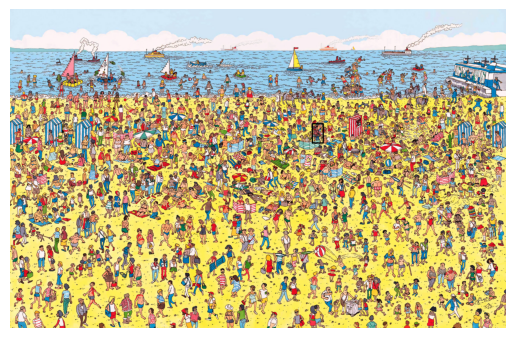

In [213]:
#This block of code displays the bounding box of the window with the highest ssd score.
img_waldo_box = cv2.rectangle(cv2.imread(filename_waldo), (best_x, best_y), (best_x + img_sliding_template.shape[1], best_y + img_sliding_template.shape[0]), (0, 0, 0), 5)
plt.imshow(cv2.cvtColor(img_waldo_box, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [214]:
def calculate_iou(pred_x, pred_y, gt_x, gt_y, template_w, template_h):
  #Get Predicted Bounding Box Coordinates
  pred_x1, pred_y1 = pred_x, pred_y
  pred_x2, pred_y2 = pred_x + template_w, pred_y + template_h

  #Get Ground Truth Bounding Box Coordinates
  gt_x1, gt_y1 = gt_x, gt_y
  gt_x2, gt_y2 = gt_x + template_w, gt_y + template_h

  #Calculate intersection rectangle coordinates
  inter_x1 = max(pred_x1, gt_x1)
  inter_y1 = max(pred_y1, gt_y1)
  inter_x2 = min(pred_x2, gt_x2)
  inter_y2 = min(pred_y2, gt_y2)

  # Calculate intersection area (0 if no overlap)
  inter_w = max(0, inter_x2 - inter_x1)
  inter_h = max(0, inter_y2 - inter_y1)
  intersection_area = inter_w * inter_h

  # Calculate union area
  pred_area = template_w * template_h
  gt_area   = template_w * template_h
  union_area = pred_area + gt_area - intersection_area

  if union_area > 0.0:
    iou = intersection_area/union_area
  else:
    iou = 0

  return iou

def calculate_accuracy(pred_x, pred_y, gt_x, gt_y, template_w, template_h, total_predictions, iou_threshold=0.5):
  iou = calculate_iou(pred_x, pred_y, gt_x, gt_y, template_w, template_h)
  is_correct = iou >= iou_threshold  # 1 if match, 0 if not
  accuracy = is_correct / total_predictions
  return accuracy

# Manually Extracted ground truth
gt_x, gt_y = 1564, 594
template_h, template_w = img_sliding_template.shape

iou = calculate_iou(best_x, best_y, gt_x, gt_y, template_w, template_h)
accuracy = calculate_accuracy(best_x, best_y, gt_x, gt_y, template_w, template_h, 1)

print(f"Predicted: ({best_x}, {best_y})")
print(f"Ground Truth: ({gt_x}, {gt_y})")
print(f"IoU: {iou:.4f}")
print(f"Accuracy (IoU >= 0.5): {accuracy}")

Predicted: (1560, 591)
Ground Truth: (1564, 594)
IoU: 0.8189
Accuracy (IoU >= 0.5): 1.0


### 1D. Analysis
Analysis: From the final IoU and Accuracy of my Template Matching Algorithm, we can see that it has sufficiently detected the window/subimage from the image since the predicted coordinate (1560, 592) is very close to the manually extracted ground truth (1564, 594), with a pixel offset of only 4 pixels on the x axis and 2 pixels in the y axis. This slight discrepancy is probably caused by the stride of 3 being used to lower the computational time. Additionallyy, an IoU of ~83% indicates a strong overlap between the predicted and ground truth bounding boxes. However, the accuracy metric here might not be fully representative since we only have a single object (since 1 correct prediction out of 1 doesn't really tell us much about the effectivity of the algorithm if applied on images with multiple objects in the same class). In Conclusion, this algorithm works well when the template and target region share a similar scale, orientation, and lighting, but may struggle in more complex scenarios with scale variation and rotation (without the implementation of image pyramids,  multiple templates, or ML-assisted sliding window)

## 2. Thresholding
Description: For this section, we will be implementing a Thresholding algorithm to seperate the background and foreground of an image. Note that Thresholding is only effective with images with foreground objects which have homogenous color, so we will be using an image of white blood cells along with its ground truth mask, which is provided from a Blood Cell Segmentation dataset in Kaggle (https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask) created by Deponker Sarker Depto and their team. For my implementation, i will be using Otsu's method, this method works by calculating the Within Class Variance of each threshold and then choosing the minimal WCV as the optimal threshold. After we find the optimal threshold, we can segment the image by marking the pixels above the threshold as the background and marking the pixels below as the foreground (since the background is relatively lighter than the foreground objects in this case). Afterwards, we will apply the Closing morphological operation to the segmented image, this operation dilates the segmented image then erodes it to fill in holes in the middle of the blood cells that the segmentation misses. As with the previous method, we will also calculate the IoU and Accuracy between the segmentation result and the ground truth mask (Please note that most of the code i wrote here reuses old code from my Digital Image Processing Assignment)

### 2A. Otsu's Thresholding

In [215]:
def find_otsu_threshold(image):
  hist, bins = np.histogram(image.flatten(), 256, [0, 256]) #Make the PDF of the histogram
  totalPixel = image.size
  normilizedProb = hist / totalPixel # Normalize the histogram for easier calculation
  intensityLevels = np.arange(256)
  #Define used variables to minimize WCI
  minVariance = float("inf")
  optimalTreshold = 0

  #Loop over every single Threshold from 0 to 255
  for T in range(256):
    #Calculate Weight, Mean, and Variance of background
    wb = np.sum(normilizedProb[:T + 1])
    if wb == 0:
      continue
    meanb_up = np.sum(intensityLevels[:T + 1] * normilizedProb[:T + 1])
    meanb = meanb_up / wb
    varianceb_up = np.sum(normilizedProb[:T + 1] * (intensityLevels[:T + 1] - meanb)**2)
    varianceb = varianceb_up / wb

    #Calculate Weight, Mean, and Variance of foreground
    wf = np.sum(normilizedProb[T + 1:])
    if wf == 0:
      break

    meanf_up = np.sum(intensityLevels[T + 1:] * normilizedProb[T + 1:])
    meanf = meanf_up / wf
    variancef_up = np.sum(normilizedProb[T + 1:] * (intensityLevels[T + 1:] - meanf)**2)
    variancef = variancef_up / wf

    #Use Otsu Method Formula
    within_class_variance = wb * varianceb + wf * variancef

    #Override Threshold if more otpimal
    if within_class_variance < minVariance:
      minVariance = within_class_variance
      optimalTreshold = T
  return optimalTreshold

### 2B. Segmentation

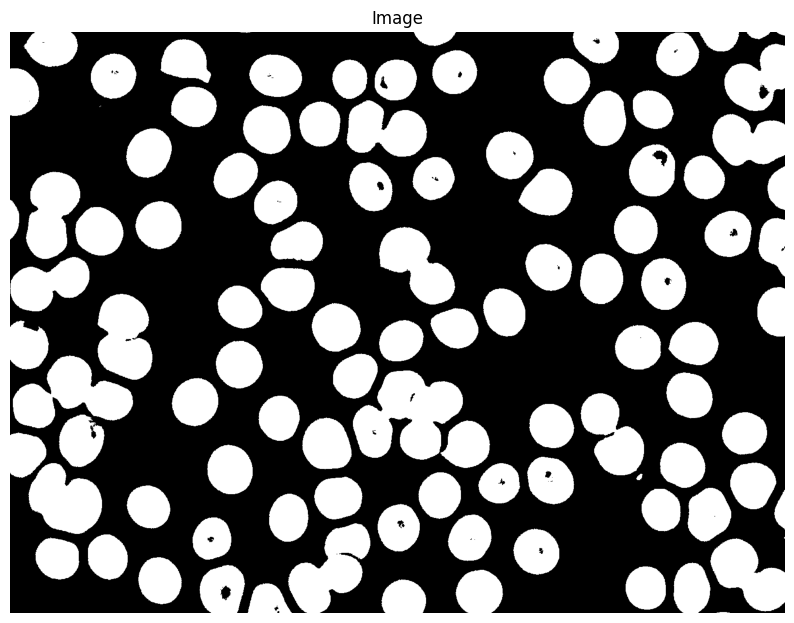

In [216]:
def segment(image):
  threshold = find_otsu_threshold(image)
  segmented_image = np.zeros(image.shape, dtype = np.uint8)
  row, col = image.shape

  for r in range(row):
    for c in range(col):
      #If image is light (like the background) mark it as background, else, mark it as foreground (blood cells)
      if image[r,c] > threshold:
        segmented_image[r,c] = 0
      else:
        segmented_image[r,c] = 255

  return segmented_image

img_segmented = segment(img_threshold)
show_image(img_segmented)

### 3C. Morphological Processes (Closing)

In [217]:
def dilate(img, kernel_size = 3):
  rows, cols = img.shape
  dilated = np.zeros_like(img)
  kernel = np.ones((kernel_size, kernel_size), dtype=int)
  k_rows, k_cols = kernel.shape
  pad_rows, pad_cols = k_rows // 2, k_cols // 2 #Calculate padding amojnt

  padded = np.pad(img, ((pad_rows, pad_rows), (pad_cols, pad_cols)), mode='constant', constant_values=0) #Pad zero to the edge of the kernel
  for i in range(rows): #Process Every pixel
    for j in range(cols):
      region = padded[i:i+k_rows,j:j+k_cols] #Find Overlapped Region
      if np.any(region * kernel): #If region and kernel overlapped change background to foreground
        dilated[i, j] = 255
      else:
        dilated[i, j] = 0
  return dilated


In [218]:
def erode(img, kernel_size = 3):
  rows, cols = img.shape
  eroded = np.zeros_like(img)
  kernel = np.ones((kernel_size, kernel_size), dtype=int)
  k_rows, k_cols = kernel.shape
  pad_rows, pad_cols = k_rows // 2, k_cols // 2 #Calculate padding amojnt

  padded = np.pad(img, ((pad_rows, pad_rows), (pad_cols, pad_cols)), mode='constant', constant_values=0) #Pad zero to the edge of the kernel
  for i in range(rows): #Process Every pixel
    for j in range(cols):
      region = padded[i:i+k_rows,j:j+k_cols] #Find Overlapped Region
      if np.all(region * kernel == 255): #Change foreground to background if region is not in all of kernel
        eroded[i, j] = 255
      else:
        eroded[i, j] = 0
  return eroded

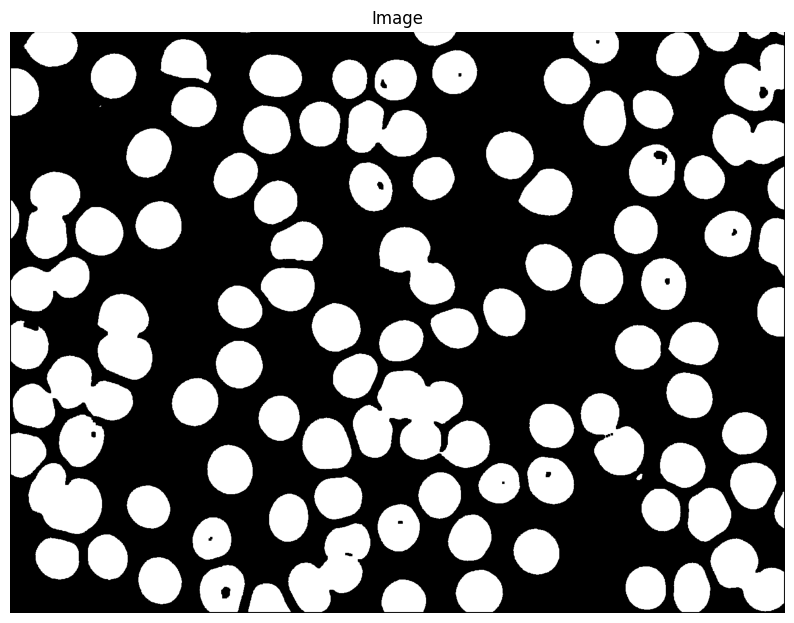

In [219]:
def closing(img, kernel_size = 3):
  dilated = dilate(img, kernel_size)
  closed = erode(dilated, kernel_size)
  return closed

closing_img = closing(img_segmented, 5)
show_image(closing_img)


In [220]:
def calculate_mask_iou(pred_mask, gt_mask):
  #Since the current value of the foreground is 255, change it to 1 to ease calulation
  pred_binary = (pred_mask > 0).astype(np.uint8)
  gt_binary = (gt_mask > 0).astype(np.uint8)

  #Calculate intersection (pixels where it is classified as foreground in the mask AND in the segmentation results)
  intersection = np.sum(pred_binary & gt_binary)

  #Calculate union (pixels where it is classified as foreground in the mask OR in the segmenation results)
  union = np.sum(pred_binary | gt_binary)

  #Calculate Intersection over Union
  if union > 0:
    iou = intersection / union
  else:
    iou = 0

  return iou

def calculate_mask_accuracy(pred_mask, gt_mask):
  pred_binary = (pred_mask > 0).astype(np.uint8)
  gt_binary   = (gt_mask > 0).astype(np.uint8)

  #Calculate Correct predictions, pixels where both masks agree (both 0 or both 1)
  correct = np.sum(pred_binary == gt_binary)
  total   = pred_mask.size  # total number of pixels

  accuracy = correct / total
  return accuracy

iou = calculate_mask_iou(img_segmented, img_threshold_mask)
accuracy = calculate_mask_accuracy(img_segmented, img_threshold_mask)

print(f"IoU: {iou:.4f}")
print(f"Accuracy: {accuracy:.4f} ({(accuracy * 100):.2f}%)")

IoU: 0.9451
Accuracy: 0.9784 (97.84%)


### 3D. Analysis
Analysis: From the IoU and Accuracy above, we can see that the segmentation results in a strong performance from the Otsu's Thresholding pipeline. With an IoU of ~94% and an accuracy of ~98%, the algorithm has successfully classifed identified the background (blood plasma) and foreground (blood cells) with a high effectivity. However, it's worth noting that i specifically used this example (blood cells) to illustrate this algorithm's capability since the color of the blood cells are homogenous. In other cases where the foreground objects and background are hetergenous or with complex lighting, the performance might degrade significantly, rendering this approach impractical.

## 3. Background Modelling
Description: For this section, we will be implementing a Background Modelling algorithm to isolate foreground objects from its background. For this method, i will be obtaining my image from Qin Bo's Research Paper titled "A Quick Self-Adaptive Background Updating Algorithm Based on Moving Region". Where I manually edited on one of their examples of an image with cars and one without from Fig. 5. With the Help of Clip Studio Paint and Aseprite, I successfully line those two images and also manually annotate the ground truth mask of the cars. This method works by calculating the absolute difference between a previously captured background model (an image without any foreground objects) and an image with foreground objects (labbeled here as current_frame). To reduce the salt and pepper noise, we apply a median filter to the difference image (I repurposed the algorithm from the first assignment here). Afterwards, we create a binary mask using Thresholding and we apply the Closing Morphological Operation to further reduce the stray pixels caused by noise.

### 3A. Median Filter

In [221]:
#Median Filter, repurposed from First Assignment of Computer Vision
def median(img):
  out = img.copy().astype(float)
  height, width = img.shape
  #Iterate with a margin of one
  for i in range(1, height - 1):
    for j in range(1, width - 1):
      #Collect 3x3
      neighbors = []
      for x in range(-1, 2):
        for y in range(-1, 2):
          neighbors.append(img[i + x, j + y])

      neighbors.sort()
      out[i, j] = neighbors[4] #Get middle value (median)
  return out

### 3B. Background Substraction

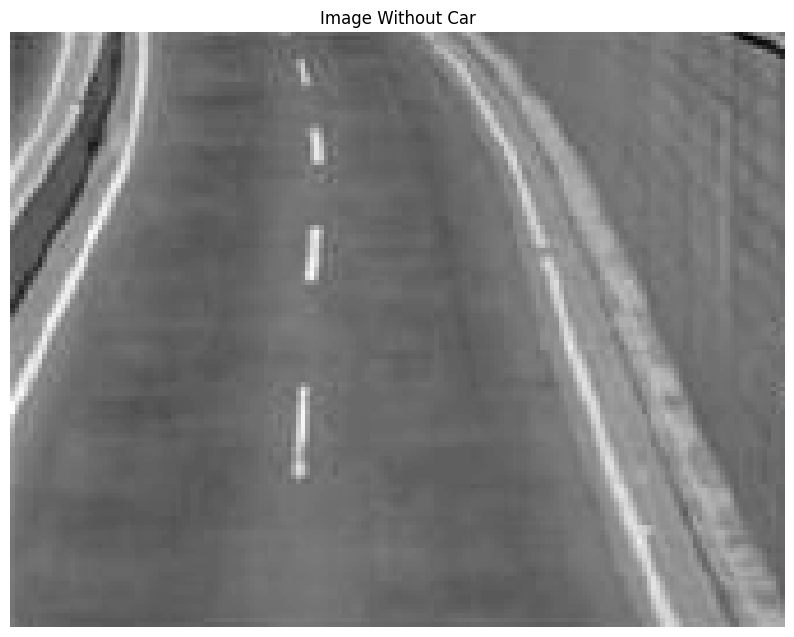

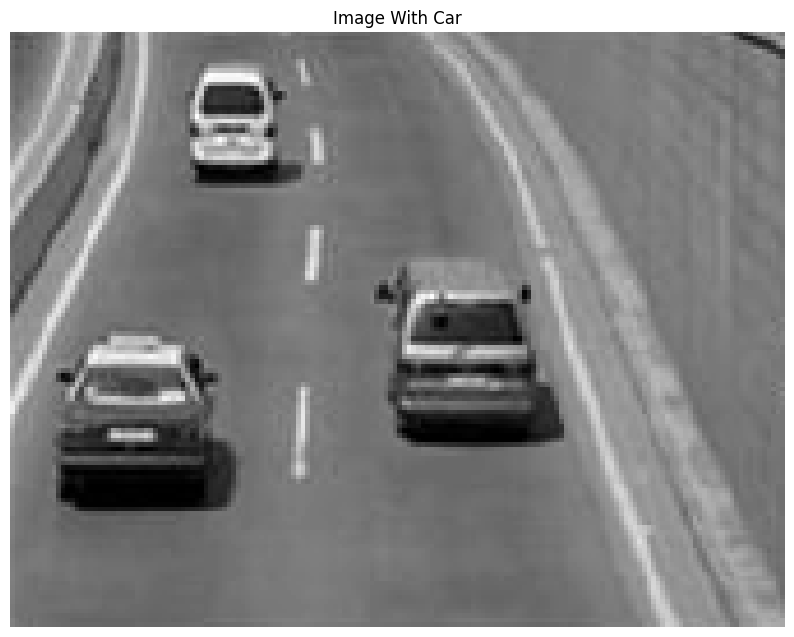

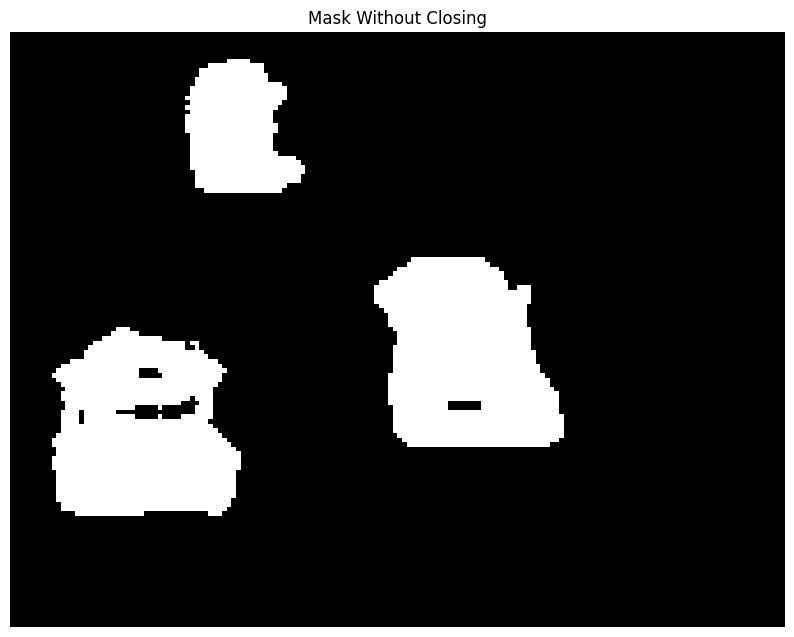

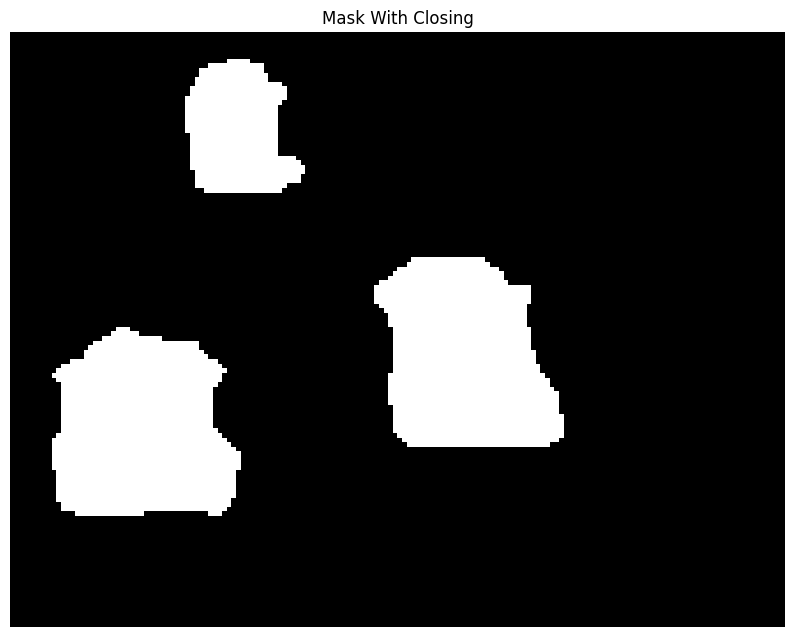

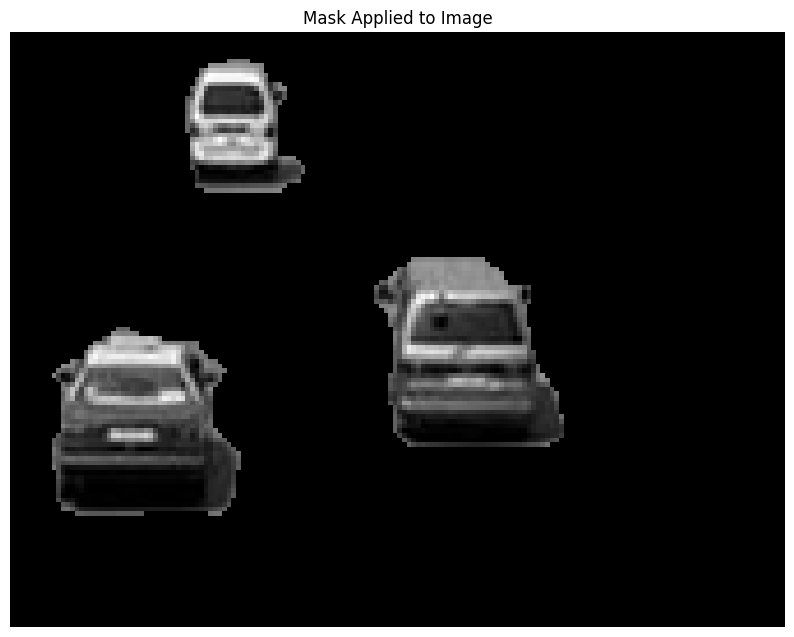

In [222]:
def background_subtraction(background, current_frame, threshold=10):
  #Make an empty image that will be used to store the difference between background and current frame
  diff = np.zeros(background.shape, dtype=np.uint8)
  rows, cols = background.shape

  #For every pixel calculate the difference between background and current frame
  for r in range(rows):
    for c in range(cols):
      diff[r, c] = abs(int(current_frame[r, c]) - int(background[r, c]))

  #Apply Median Filter to the difference
  diff = median(diff)

  #Create a binary mask from the difference image
  foreground_mask = np.zeros(background.shape, dtype=np.uint8)
  for r in range(rows):
    for c in range(cols):
      if diff[r, c] > threshold:
        foreground_mask[r, c] = 255
      else:
        foreground_mask[r, c] = 0

  #Apply Closing to fix noise
  closed_mask = closing(foreground_mask, 5)
  masked_image = current_frame * (closed_mask // 255)

  return foreground_mask, closed_mask, masked_image

pred_mask_no_closing, pred_mask, masked_image = background_subtraction(img_background_nocar, img_background_car, threshold=10)

show_image(img_background_nocar, "Image Without Car")
show_image(img_background_car, "Image With Car")
show_image(pred_mask_no_closing, "Mask Without Closing")
show_image(pred_mask, "Mask With Closing")
show_image(masked_image, "Mask Applied to Image")

### 3C. Evaluation

In [223]:
iou = calculate_mask_iou(pred_mask, img_background_mask)
accuracy = calculate_mask_accuracy(pred_mask, img_background_mask)

print(f"IoU: {iou:.4f}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

IoU: 0.9035
Accuracy: 0.9856 (98.56%)


### 3D. Analysis
Analysis: My background substraction/modelling pipeline has achieved an IoU of ~90% and an accuracy of ~99%, demonstrating a strong performance overall. However, like the previous two methods, it's important to note that i chose this case specifically, and that this pipeline might not work for every case. First of all, this pipeline would only work with static camera position, it won't work if the camera is moving since the algorithm will not be able to capture a "model" of the background if the background is constantly updating. The same logic applies with dynamically changing illumination (such as day -> night transitions), although that problem might be solvable by periodically updating the background model. Additionally, any disturbance to the camera's position might worsen this pipeline's performance significantly since it will create an offset between the current frame and the background model.